<a href="https://colab.research.google.com/github/Rojoniaina-Rasoafarihy/Evo2_project/blob/main/classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

In [ ]:
# Load embeddings and labels
LABEL_FILE = "gs://rojo_project/isolation_source_labels.csv"

In [ ]:
!mkdir -p /home/jupyter/data

In [ ]:
!gsutil -m cp -r gs://rojo_project/evo2_embeddings_npz /home/jupyter/data/

In [ ]:
!ls /home/jupyter/data

evo2_embeddings_npz


In [ ]:
import os
EMB_DIR = "/home/jupyter/data/evo2_embeddings_npz"

all_embeddings = []
all_labels = []

files = [f for f in os.listdir(EMB_DIR) if f.endswith(".npz")]

print("Embedding files:", len(files))

Embedding files: 29920


In [ ]:
# Load labels

label_df = pd.read_csv(LABEL_FILE)
label_dict = dict(zip(label_df["Assembly"], label_df["isolation source"]))

X_list = []
y_list = []
stems = []

EMB_DIR = Path("/home/jupyter/data/evo2_embeddings_npz")

for npz_path in EMB_DIR.glob("*.npz"):
    stem = npz_path.stem
    if stem not in label_dict:
        continue
    data = np.load(npz_path)
    X_list.append(data["embedding"])
    y_list.append(label_dict[stem])
    stems.append(stem)

X = np.array(X_list)          # (n_samples, 8192)
y = np.array(y_list)

# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f"Classes: {le.classes_}")

Classes: ['Air' 'Bird' 'Bloodstream' 'Bone_Joint' 'CF_Respiratory' 'Crop'
 'Domestic' 'Ear_Nose_Throat' 'Experimental' 'Gastrointestinal' 'Hospital'
 'Industrial' 'Lab_Strain' 'Marine' 'Medical_Device' 'Ocular'
 'Reproductive' 'Respiratory' 'Skin_Soft_Tissue' 'Soil' 'Urinary' 'Water']


In [ ]:
# Define mapping for merging rare classes
merge_mapping = {
    'Air': 'Other_Environmental',
    'Crop': 'Other_Environmental',
    'Domestic': 'Other_Environmental',
    'Industrial': 'Other_Environmental',
    'Lab_Strain': 'Other_Environmental',
    'Marine': 'Other_Environmental',
    'Soil': 'Other_Environmental',
    'Water': 'Other_Environmental',
    'Medical_Device': 'Other_Clinical',
    'Hospital': 'Other_Clinical',
    'Experimental': 'Other_Clinical',
    'Ear_Nose_Throat': 'Other_Clinical',
    'Skin_Soft_Tissue': 'Other_Clinical',
    'Ocular': 'Other_Clinical',
    'Reproductive': 'Other_Clinical',
    'Bird': 'Animal_Clinical',
    'Bone_Joint': 'Animal_Clinical',
    'CF_Respiratory': 'Respiratory',  # merge with existing Respiratory
}

In [ ]:
# Apply mapping
y_merged = [merge_mapping.get(label, label) for label in y]

# Count after merging
class_counts = Counter(y_merged)
print("Classes after merging:")
for cls, cnt in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f"  {cls}: {cnt}")

Classes after merging:
  Respiratory: 15558
  Other_Clinical: 5362
  Urinary: 3383
  Bloodstream: 2430
  Other_Environmental: 1767
  Gastrointestinal: 1315
  Animal_Clinical: 105


In [ ]:

# Keep only classes with at least `min_samples`

min_samples = 10
keep_classes = [cls for cls, cnt in class_counts.items() if cnt >= min_samples]
print(f"\nKeeping classes with ≥{min_samples} samples: {keep_classes}")

mask = [label in keep_classes for label in y_merged]
X_filtered = X[mask]
y_filtered = [y_merged[i] for i in range(len(mask)) if mask[i]]

# Encode labels to integers
le = LabelEncoder()
y_enc = le.fit_transform(y_filtered)
class_names = le.classes_
print(f"\nFinal classes: {class_names}")
print(f"Class counts: {dict(zip(class_names, Counter(y_enc).values()))}")


Keeping classes with ≥10 samples: [np.str_('Respiratory'), np.str_('Bloodstream'), 'Other_Clinical', np.str_('Urinary'), 'Other_Environmental', np.str_('Gastrointestinal'), 'Animal_Clinical']

Final classes: ['Animal_Clinical' 'Bloodstream' 'Gastrointestinal' 'Other_Clinical'
 'Other_Environmental' 'Respiratory' 'Urinary']
Class counts: {np.str_('Animal_Clinical'): 15558, np.str_('Bloodstream'): 2430, np.str_('Gastrointestinal'): 5362, np.str_('Other_Clinical'): 3383, np.str_('Other_Environmental'): 1767, np.str_('Respiratory'): 1315, np.str_('Urinary'): 105}


In [ ]:
#  5‑fold stratified cross‑validation

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Storage
all_y_true = []
all_y_pred = []
all_y_proba = []

fold_accuracies = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_filtered, y_enc)):
    X_train, X_test = X_filtered[train_idx], X_filtered[test_idx]
    y_train, y_test = y_enc[train_idx], y_enc[test_idx]

    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # PCA (reduce to 50 components or min available)
    n_comp = min(50, X_train_scaled.shape[1], X_train_scaled.shape[0] - 1)
    pca = PCA(n_components=n_comp, random_state=42)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # Logistic Regression (increase max_iter to ensure convergence)
    clf = LogisticRegression(max_iter=3000, random_state=42, solver='lbfgs')
    clf.fit(X_train_pca, y_train)

    y_pred = clf.predict(X_test_pca)
    y_proba = clf.predict_proba(X_test_pca)   # shape (n_test, n_classes)

    acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(acc)
    print(f"Fold {fold+1} accuracy: {acc:.4f}")

    # Collect
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_proba.append(y_proba)

# Combine probabilities from all folds
all_y_proba = np.vstack(all_y_proba)

Fold 1 accuracy: 0.5184
Fold 2 accuracy: 0.5187
Fold 3 accuracy: 0.5192
Fold 4 accuracy: 0.5222
Fold 5 accuracy: 0.5167


In [ ]:

#Overall performance metrics

print(f"\nMean CV accuracy: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")

# Classification report (text)
print("\nClassification Report (all folds combined):")
print(classification_report(all_y_true, all_y_pred, target_names=class_names))

# ROC‑AUC (one‑vs‑rest, macro average)
# Requires at least 2 classes and probabilities for all classes
if len(class_names) >= 2:
    auc_macro = roc_auc_score(all_y_true, all_y_proba, multi_class='ovr', average='macro')
    print(f"\nMacro ROC‑AUC: {auc_macro:.4f}")
else:
    print("\nROC‑AUC not computed (only one class).")


Mean CV accuracy: 0.5191 (+/- 0.0018)

Classification Report (all folds combined):
                     precision    recall  f1-score   support

    Animal_Clinical       0.00      0.00      0.00       105
        Bloodstream       0.20      0.00      0.00      2430
   Gastrointestinal       0.16      0.01      0.02      1315
     Other_Clinical       0.32      0.06      0.10      5362
Other_Environmental       0.53      0.02      0.04      1767
        Respiratory       0.53      0.97      0.68     15558
            Urinary       0.22      0.01      0.01      3383

           accuracy                           0.52     29920
          macro avg       0.28      0.15      0.12     29920
       weighted avg       0.41      0.52      0.38     29920


Macro ROC‑AUC: 0.6646


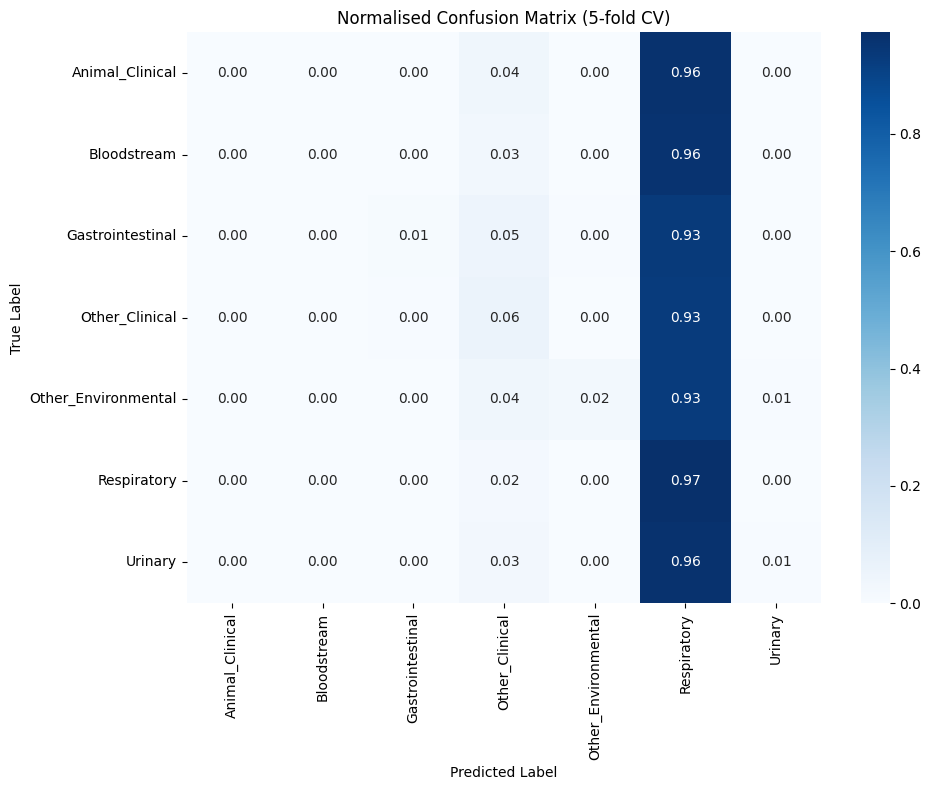

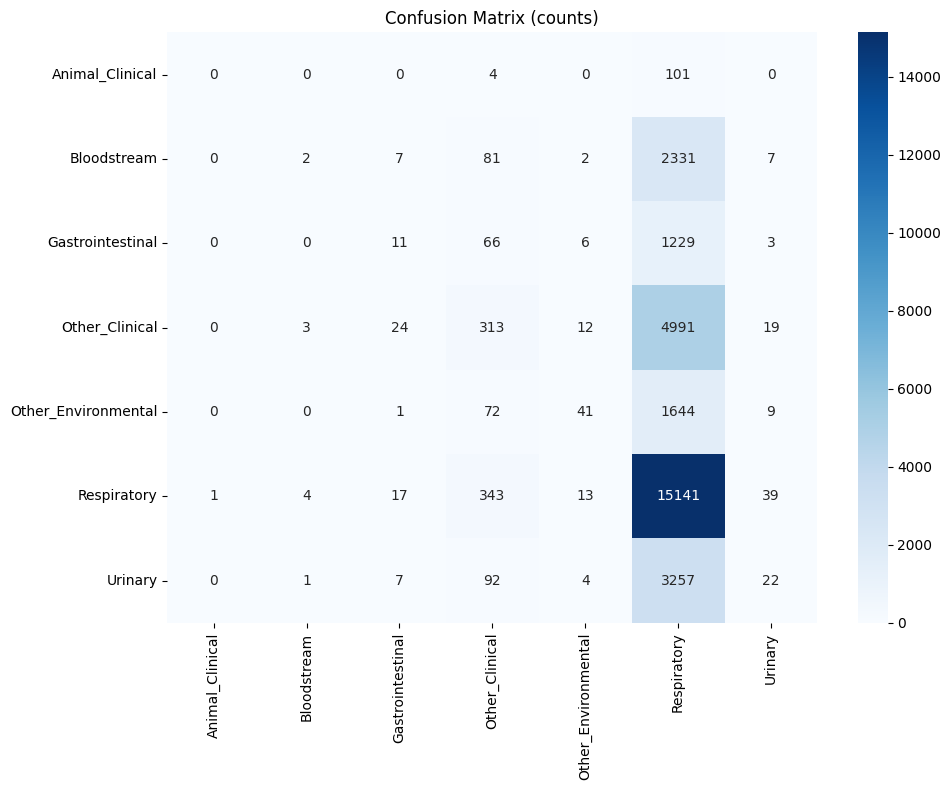

In [ ]:
#Confusion Matrix (normalised and raw)

cm = confusion_matrix(all_y_true, all_y_pred)
# Normalised by row (true class)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalised Confusion Matrix (5‑fold CV)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Also save raw counts version
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (counts)')
plt.tight_layout()
plt.savefig('confusion_matrix_counts.png', dpi=150)
plt.show()